In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [3]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

In [8]:
def bmi_label_check(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Consider healthy weight gain"
    elif 18.5 <= bmi < 24.9:
        state["category"] = "Maintain current healthy lifestyle"
    elif 25 <= bmi < 29.9:
        state["category"] = "Consider weight-management strategies"
    else:
        state["category"] = "Consider professional weight-management support"

    return state

In [ ]:

graph = StateGraph(BMIState)


graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('bmi_label_check', bmi_label_check)


graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'bmi_label_check')
graph.add_edge('bmi_label_check', END)



workflow = graph.compile()

In [12]:
intial_state = {'weight_kg':100, 'height_m':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 100, 'height_m': 1.73, 'bmi': 33.41, 'category': 'Consider professional weight-management support'}


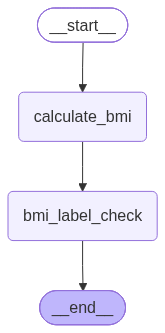

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())